In [47]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants
from mpl_toolkits.mplot3d.axes3d import Axes3D # 3D 
from matplotlib import markers
import matplotlib.ticker as ticker
q = 1.602176634e-19
eps0 = 8.854187817e-12
kB_eV = 8.617333262e-5
T = 300
eps_r = 3.5
eps = eps_r * eps0
Phi_b = 1.0
sigma_i = 0.10
L = 200e-9
# constants
A = 1.0          # m^2（如果只比较趋势，可以设为1）
Nt = 1.0         # m^-3（归一化即可）
mu0 = 1e-8       # m^2/(V·s)
Ci = 0.42
sigma_b = 0.09   # eV
h = 4.135667696e-15      # eV·s
c = scipy.constants.c
kB_eV = 8.617333262e-5   # eV/K
q = 1.602176634e-19      # Elementary charge [C]
E0 = 1.0                 # eV

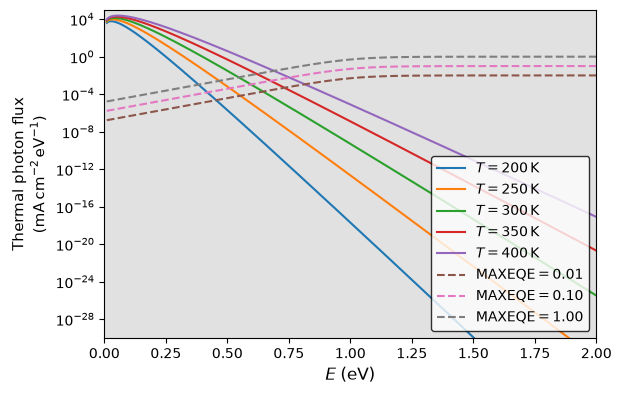

In [48]:
fig = plt.figure(figsize=(6, 4),facecolor="#ffffff")
left, bottom, width, height = 0.12, 0.12, 0.82, 0.82
ax = fig.add_axes((left, bottom, width, height),facecolor="#e1e1e1")

Ts = np.array([200,250,300,350,400])   # K

E = np.linspace(0.01, 2.0, 1000)   # eV

for T in Ts:
        phi_one_side = 2 * np.pi/ (h**3 * c**2)* E**2/ np.expm1(E / (kB_eV * T))
    
        phi_two_sides = 2 * phi_one_side

        phi_current = q * phi_two_sides * 0.1

        ax.semilogy(E,phi_current,linewidth=1.5,linestyle="-",label=rf"$T={T}\,\mathrm{{K}}$")

ax.set_xlim(0, 2)
ax.set_ylim(1e-30, 1e5)
ax.set_xlabel(r"$E\;(\mathrm{eV})$",fontsize=12)
ax.set_ylabel(
    r"Thermal photon flux"
    "\n"
    r"$(\mathrm{mA\,cm^{-2}\,eV^{-1}})$",
    fontsize=11)

# ============================================================

MEQES = np.array([0.01,0.1,1.0])

for MEQE in MEQES:
    EQE = MEQE / (1 + np.exp((E0 - E) / sigma_b))
    ax.semilogy(E, EQE, linewidth=1.5, linestyle="--", label=rf"$\mathrm{{MAXEQE}}={MEQE:.2f}$")
ax.legend(loc=4,fontsize=10,frameon=True,edgecolor="black")


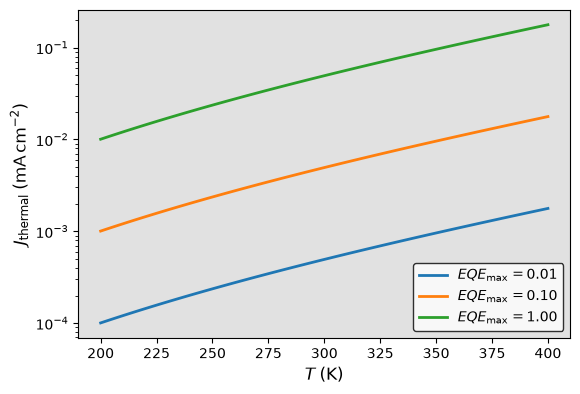

In [50]:
E = np.linspace(0.01, 2.0, 3000)   # eV

MEQES = np.array([0.01, 0.10, 1.00])

T_values = np.linspace(200, 400, 101)

def eqe_function(E, max_eqe, E0, sigma):
    return max_eqe / (
        1 + np.exp((E0 - E) / sigma)
    )

def thermal_current_spectrum(E, T):
    # Equation (10): one-side photon flux
    phi_one_side = (
        2 * np.pi
        / (h**3 * c**2)
        * E**2
        / np.expm1(E / (kB_eV * T))
    )
    phi_two_sides = 2 * phi_one_side
    return q * phi_two_sides * 0.1


# ============================================================
# 对每一个温度积分

J_results = {}
for max_eqe in MEQES:

    EQE = eqe_function(E,max_eqe,E0,sigma_b)

    J_list = []
    for T in T_values:
        q_phi = thermal_current_spectrum(E, T)
        integrand = EQE * q_phi         # 被积函数
        J = np.trapezoid(integrand, E)          # 对能量积分
        J_list.append(J)

    J_results[max_eqe] = np.array(J_list)

# ============================================================

fig = plt.figure(figsize=(6, 4),facecolor="#ffffff")
ax = fig.add_axes((0.14, 0.14, 0.82, 0.82),facecolor="#e1e1e1")

for max_eqe in MEQES:
    ax.semilogy(T_values,J_results[max_eqe],
        linewidth=2,label=rf"$EQE_{{\max}}={max_eqe:.2f}$")

ax.set_xlabel(r"$T\;(\mathrm{K})$",fontsize=12)

ax.set_ylabel(r"$J_{\mathrm{thermal}}\;(\mathrm{mA\,cm^{-2}})$",
    fontsize=12)
ax.legend(loc=4,fontsize=10,frameon=True,edgecolor="black")